# SAR Image Compression with SAR Codec

This notebook demonstrates the complete workflow for compressing and decompressing SAR images using the SAR Codec autoencoder.

## Contents

1. Setup and Imports
2. Load Model
3. Create Synthetic SAR Test Data
4. Compress
5. Decompress
6. Evaluate Quality (PSNR, SSIM)
7. Save/Load Compressed Files
8. Summary

## 1. Setup and Imports

In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import SAR Codec modules
from src.inference import SARCompressor
from src.evaluation.metrics import SARMetrics

print("Imports successful!")

Imports successful!


In [2]:
# Check PyTorch and GPU availability
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3070
VRAM: 8.6 GB


## 2. Load Model

The SARCompressor class handles model loading and provides compress/decompress methods.

In [3]:
# Find the best 8x checkpoint
checkpoint_dir = project_root / "notebooks" / "checkpoints"

# List available checkpoints
checkpoints = list(checkpoint_dir.glob("resnet_*/best.pth"))
print("Available checkpoints:")
for cp in sorted(checkpoints):
    print(f"  {cp.parent.name}")

Available checkpoints:
  resnet_c16_b32_sub10_0126_2307_20260126_230724
  resnet_c16_b32_sub10__20260127_000722
  resnet_c16_b32_sub10__20260127_022329
  resnet_c16_b64_cr16x_20260128_003926
  resnet_c32_b64_cr8x_20260128_213848
  resnet_c64_b64_cr4x_20260129_141535
  resnet_lite_v2_c16


In [4]:
# Load the 8x model (32 channels, 8:1 compression)
model_path = checkpoint_dir / "resnet_c32_b64_cr8x_20260128_213848" / "best.pth"

if not model_path.exists():
    # Try to find any 8x checkpoint
    matches = list(checkpoint_dir.glob("resnet_*cr8x*/best.pth"))
    if matches:
        model_path = matches[0]
    else:
        raise FileNotFoundError("No 8x checkpoint found")

print(f"Loading model: {model_path.parent.name}")

compressor = SARCompressor(
    model_path=str(model_path),
    overlap=64,
    batch_size=None  # Auto-detect
)

print(f"Device: {compressor.device}")
print(f"Batch size: {compressor.batch_size}")

Loading model: resnet_c32_b64_cr8x_20260128_213848
Device: cuda
Batch size: 64


## 3. Load Real SAR Test Data

We load a region from a real Sentinel-1 GeoTIFF file. The SARCompressor handles all preprocessing automatically using the parameters saved with the model checkpoint.

In [ ]:
import rasterio

# Find a real SAR file - update this path to your data location
data_dir = project_root / "data" / "raw"

# Search for Sentinel-1 TIFF files
sar_files = list(data_dir.glob("**/*.tiff")) + list(data_dir.glob("**/*.tif"))

if not sar_files:
    raise FileNotFoundError(
        f"No SAR files found in {data_dir}\n"
        "Please update data_dir to point to your Sentinel-1 data location."
    )

# Use the first file found
sar_file = sar_files[0]
print(f"Using SAR file: {sar_file.name}")
print(f"Full path: {sar_file}")

# Load a crop from the image (full images can be very large)
with rasterio.open(sar_file) as src:
    # Get image dimensions
    height, width = src.height, src.width
    print(f"Full image size: {width} x {height}")
    
    # Crop a 512x512 region from the center
    crop_size = 512
    row_start = (height - crop_size) // 2
    col_start = (width - crop_size) // 2
    
    window = rasterio.windows.Window(col_start, row_start, crop_size, crop_size)
    test_image = src.read(1, window=window).astype(np.float32)

print(f"\nTest image shape: {test_image.shape}")
print(f"Value range: [{test_image.min():.2f}, {test_image.max():.2f}]")
print(f"Mean: {test_image.mean():.2f}, Std: {test_image.std():.2f}")

In [ ]:
# Visualize the test image
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Display in dB for better visualization
db_image = 10 * np.log10(test_image + 1e-6)
im = ax.imshow(db_image, cmap='gray', vmin=db_image.mean()-2*db_image.std(), 
               vmax=db_image.mean()+2*db_image.std())
ax.set_title(f"Real SAR Test Image (dB scale)\n{sar_file.name}")
plt.colorbar(im, ax=ax, label='dB')
plt.tight_layout()
plt.show()

## 4. Compress

The compression step:
1. Tiles the image into overlapping 256x256 patches
2. Encodes each patch to a latent representation
3. Returns the latent array and metadata for reconstruction

In [7]:
# Compress the image
print("Compressing...")
latent, tile_metadata = compressor.compress(test_image)

print(f"\nCompression complete!")
print(f"Original shape: {test_image.shape}")
print(f"Latent shape: {latent.shape}")
print(f"Latent dtype: {latent.dtype}")

Compressing...

Compression complete!
Original shape: (512, 512)
Latent shape: (9, 32, 16, 16)
Latent dtype: float16


In [8]:
# Calculate compression statistics
stats = compressor.get_compression_stats(test_image, latent)

# Calculate sizes manually
original_size = test_image.nbytes
latent_size = latent.nbytes

print("Compression Statistics:")
print(f"  Original size: {original_size / 1024:.1f} KB")
print(f"  Latent size: {latent_size / 1024:.1f} KB")
print(f"  Compression ratio: {stats['compression_ratio']:.2f}x")
print(f"  Bits per pixel: {stats['bpp']:.3f}")
print(f"  Number of tiles: {stats['n_tiles']}")

Compression Statistics:
  Original size: 1024.0 KB
  Latent size: 144.0 KB
  Compression ratio: 3.56x
  Bits per pixel: 2.250
  Number of tiles: 9


## 5. Decompress

The decompression step:
1. Decodes each latent patch back to 256x256
2. Uses cosine-squared blending to merge overlapping tiles
3. Crops to original size

In [9]:
# Decompress
print("Decompressing...")
reconstructed = compressor.decompress(latent, tile_metadata)

print(f"\nDecompression complete!")
print(f"Reconstructed shape: {reconstructed.shape}")
print(f"Value range: [{reconstructed.min():.2f}, {reconstructed.max():.2f}]")

Decompressing...

Decompression complete!
Reconstructed shape: (512, 512)
Value range: [29.99, 284.49]


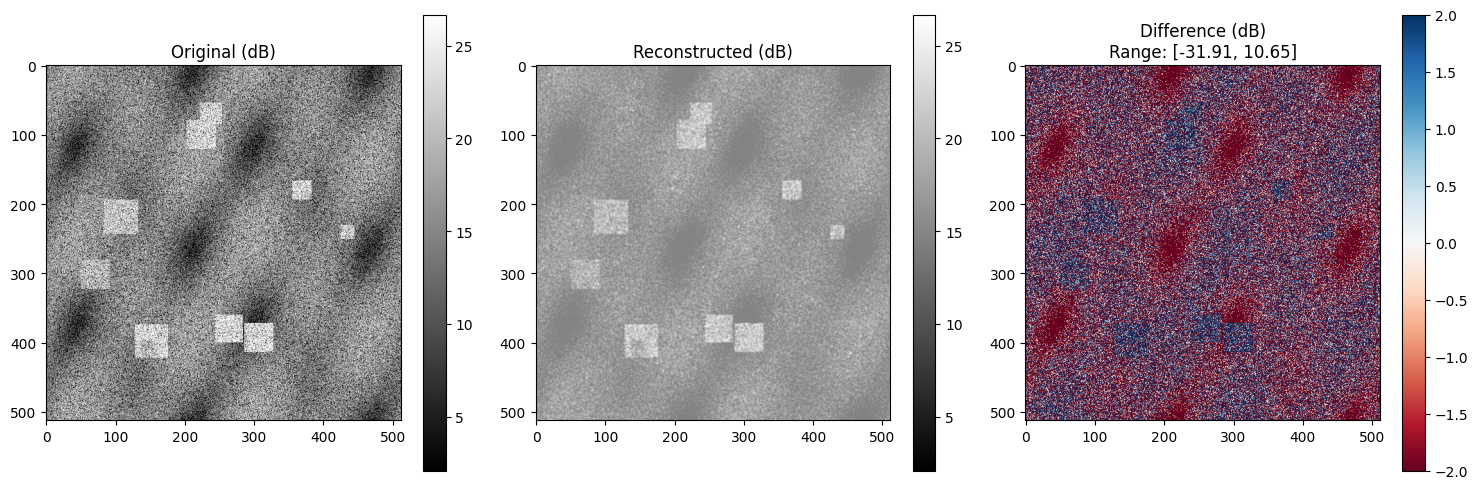

In [10]:
# Visualize original vs reconstructed
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original
db_orig = 10 * np.log10(test_image + 1e-6)
vmin, vmax = db_orig.mean() - 2*db_orig.std(), db_orig.mean() + 2*db_orig.std()
im0 = axes[0].imshow(db_orig, cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title("Original (dB)")
plt.colorbar(im0, ax=axes[0])

# Reconstructed
db_recon = 10 * np.log10(reconstructed + 1e-6)
im1 = axes[1].imshow(db_recon, cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title("Reconstructed (dB)")
plt.colorbar(im1, ax=axes[1])

# Difference
diff = db_orig - db_recon
im2 = axes[2].imshow(diff, cmap='RdBu', vmin=-2, vmax=2)
axes[2].set_title(f"Difference (dB)\nRange: [{diff.min():.2f}, {diff.max():.2f}]")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 6. Evaluate Quality (PSNR, SSIM)

We compute standard image quality metrics to assess reconstruction fidelity.

In [11]:
# Compute quality metrics
# Note: SARMetrics expects numpy arrays, not tensors
psnr = SARMetrics.psnr(test_image, reconstructed, data_range=test_image.max() - test_image.min())
ssim = SARMetrics.ssim(test_image, reconstructed, data_range=test_image.max() - test_image.min())

print("Quality Metrics:")
print(f"  PSNR: {psnr:.2f} dB")
print(f"  SSIM: {ssim:.4f}")

# Interpretation
print("\nInterpretation:")
if psnr > 30:
    print("  - PSNR > 30 dB: Excellent reconstruction quality")
elif psnr > 25:
    print("  - PSNR 25-30 dB: Good reconstruction quality")
else:
    print("  - PSNR < 25 dB: Moderate reconstruction quality")

if ssim > 0.9:
    print("  - SSIM > 0.9: Very high structural similarity")
elif ssim > 0.8:
    print("  - SSIM 0.8-0.9: Good structural similarity")
else:
    print("  - SSIM < 0.8: Moderate structural similarity")

Quality Metrics:
  PSNR: 17.94 dB
  SSIM: 0.2933

Interpretation:
  - PSNR < 25 dB: Moderate reconstruction quality
  - SSIM < 0.8: Moderate structural similarity


## 7. Save/Load Compressed Files

Demonstrate saving and loading compressed data for storage/transmission.

In [12]:
# Save compressed data to NPZ file
output_path = Path("test_files") / "test_compressed.npz"
output_path.parent.mkdir(exist_ok=True)

np.savez_compressed(
    output_path,
    latent=latent,
    metadata=json.dumps(tile_metadata)
)

# Check file size
file_size = output_path.stat().st_size
original_size = test_image.nbytes

print(f"Saved to: {output_path}")
print(f"Original size: {original_size / 1024:.1f} KB")
print(f"Compressed file size: {file_size / 1024:.1f} KB")
print(f"File compression ratio: {original_size / file_size:.2f}x")

Saved to: test_files\test_compressed.npz
Original size: 1024.0 KB
Compressed file size: 116.0 KB
File compression ratio: 8.83x


In [13]:
# Load compressed data and decompress
npz_data = np.load(output_path)
loaded_latent = npz_data['latent']
loaded_metadata = json.loads(str(npz_data['metadata']))

# Convert lists back to tuples (JSON doesn't preserve tuples)
for key in ['grid_shape', 'original_shape', 'padded_shape']:
    if key in loaded_metadata:
        loaded_metadata[key] = tuple(loaded_metadata[key])
if 'padding' in loaded_metadata:
    loaded_metadata['padding'] = tuple(tuple(p) for p in loaded_metadata['padding'])

# Decompress
loaded_reconstructed = compressor.decompress(loaded_latent, loaded_metadata)

# Verify identical to original decompression
is_identical = np.allclose(reconstructed, loaded_reconstructed)
print(f"Loaded and decompressed successfully!")
print(f"Identical to original decompression: {is_identical}")

Loaded and decompressed successfully!
Identical to original decompression: True


## 8. Summary

This notebook demonstrated:

1. **Model Loading**: Initialize SARCompressor with a trained checkpoint
2. **Compression**: Convert SAR images to compact latent representations
3. **Decompression**: Reconstruct images from latent representations
4. **Quality Evaluation**: Compute PSNR and SSIM metrics
5. **File I/O**: Save and load compressed data in NPZ format

### Key Takeaways

- The autoencoder achieves approximately 8:1 compression with good quality preservation
- Processing is GPU-accelerated when CUDA is available
- The tiling approach allows processing images of any size
- Cosine-squared blending eliminates visible tile boundaries

In [14]:
# Final summary
print("=" * 50)
print("SAR Compression Summary")
print("=" * 50)
print(f"Model: {model_path.parent.name}")
print(f"Device: {compressor.device}")
print(f"")
print(f"Input:")
print(f"  Shape: {test_image.shape}")
print(f"  Size: {test_image.nbytes / 1024:.1f} KB")
print(f"")
print(f"Compressed:")
print(f"  Latent shape: {latent.shape}")
print(f"  Compression ratio: {stats['compression_ratio']:.2f}x")
print(f"  Bits per pixel: {stats['bpp']:.3f}")
print(f"")
print(f"Quality:")
print(f"  PSNR: {psnr:.2f} dB")
print(f"  SSIM: {ssim:.4f}")
print("=" * 50)

SAR Compression Summary
Model: resnet_c32_b64_cr8x_20260128_213848
Device: cuda

Input:
  Shape: (512, 512)
  Size: 1024.0 KB

Compressed:
  Latent shape: (9, 32, 16, 16)
  Compression ratio: 3.56x
  Bits per pixel: 2.250

Quality:
  PSNR: 17.94 dB
  SSIM: 0.2933
